# Module 1: Corporate Project Evaluation & Ranking with ML

## Objective
Build an ML-powered system to rank corporate projects for funding based on:
- **NPV & Cash Flow Forecasting** (Regression)
- **Success Probability Prediction** (Classification)
- **Risk-Adjusted Return Analysis**
- **Executive Explanations** (SHAP)

## Output Deliverables
1. Ranked project list with recommendations (Fund/Review/Hold)
2. SHAP visualizations explaining key drivers
3. Model performance metrics & confidence scores
4. Dashboard-ready JSON/CSV outputs

---

## PHASE 1: Data Preparation & Exploration

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [208]:
# Load dataset
data_path = '../data/corporate_projects-1.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (50, 10)

First few rows:
   Project_ID  Department  Investment_Cost  Expected_Cashflow_Year1  \
0           1  Operations           184654                   583556   
1           2   Marketing          2054354                  1447527   
2           3     Finance          2516182                  1372905   
3           4  Operations          3574675                  1817640   
4           5  Operations          2752991                   792139   

   Expected_Cashflow_Year2  Expected_Cashflow_Year3  Historical_ROI  \
0                  2348816                  1888756            0.08   
1                   541234                   278576            0.15   
2                  1998260                  2312990            0.19   
3                   189182                  1434250            0.22   
4                  1571101                   111087            0.12   

   Market_Growth Project_Risk  Success  
0           0.05          Low        0  
1          -0.01       

In [209]:
# Data quality checks
print("="*50)
print("DATA QUALITY SUMMARY")
print("="*50)

# Descriptive statistics
print(f"\nDescriptive Statistics:")
print(df.describe())

# Value counts for categorical variables
print(f"\nDepartment Distribution:")
print(df['Department'].value_counts())

print(f"\nRisk Distribution:")
print(df['Project_Risk'].value_counts())

print(f"\nSuccess Distribution (Target Variable):")
print(df['Success'].value_counts())
print(f"Success Rate: {df['Success'].mean()*100:.2f}%")

DATA QUALITY SUMMARY

Descriptive Statistics:
       Project_ID  Investment_Cost  Expected_Cashflow_Year1  \
count    50.00000     5.000000e+01             5.000000e+01   
mean     25.50000     2.508812e+06             1.019832e+06   
std      14.57738     1.250287e+06             5.953064e+05   
min       1.00000     1.232470e+05             6.266600e+04   
25%      13.25000     1.731652e+06             5.329580e+05   
50%      25.50000     2.685838e+06             1.037420e+06   
75%      37.75000     3.480671e+06             1.475176e+06   
max      50.00000     4.898669e+06             1.936222e+06   

       Expected_Cashflow_Year2  Expected_Cashflow_Year3  Historical_ROI  \
count             5.000000e+01             5.000000e+01       50.000000   
mean              1.245896e+06             1.513842e+06        0.165600   
std               7.558611e+05             8.965712e+05        0.058699   
min               7.195900e+04             8.935300e+04        0.050000   
25%        

## PHASE 2: Feature Engineering

In [210]:
# Create a copy for feature engineering
df_processed = df.copy()

# 1. Calculate total expected cashflow
cf_cols = ['Expected_Cashflow_Year1', 'Expected_Cashflow_Year2', 'Expected_Cashflow_Year3']
df_processed['Total_Expected_Cashflow'] = df_processed[cf_cols].sum(axis=1)

# 2. Calculate cashflow stability (coefficient of variation)
df_processed['Cashflow_Stability'] = df_processed[cf_cols].std(axis=1) / (df_processed[cf_cols].mean(axis=1) + 1e-6)

# 3. Average annual cashflow
df_processed['Avg_Annual_Cashflow'] = df_processed['Total_Expected_Cashflow'] / 3

# 4. Simple payback period (Investment_Cost / Avg_Annual_Cashflow)
df_processed['Simple_Payback_Period'] = df_processed['Investment_Cost'] / (df_processed['Avg_Annual_Cashflow'] + 1e-6)

# 5. Investment intensity (Investment relative to total cashflow)
df_processed['Investment_Intensity'] = df_processed['Investment_Cost'] / (df_processed['Total_Expected_Cashflow'] + 1e-6)

# 6. Interaction: ROI × Market Growth
df_processed['ROI_Market_Growth_Interaction'] = df_processed['Historical_ROI'] * df_processed['Market_Growth']

# 7. Interaction: Investment × Risk (higher cost + higher risk = more concern)
df_processed['Risk_Encoded'] = df_processed['Project_Risk'].map({'Low': 1, 'Medium': 2, 'High': 3})
df_processed['Investment_Risk_Score'] = df_processed['Investment_Cost'] * df_processed['Risk_Encoded']

# 8. Revenue to cost ratio
df_processed['Revenue_Cost_Ratio'] = df_processed['Total_Expected_Cashflow'] / df_processed['Investment_Cost']# payback ratio

print("✓ Features engineered successfully")
print(f"\nNew features created:")
new_features = ['Total_Expected_Cashflow', 'Cashflow_Stability', 'Avg_Annual_Cashflow', 
                'Simple_Payback_Period', 'Investment_Intensity', 'ROI_Market_Growth_Interaction',
                'Investment_Risk_Score', 'Revenue_Cost_Ratio', 'Risk_Encoded']
print(df_processed[new_features].head())

✓ Features engineered successfully

New features created:


   Total_Expected_Cashflow  Cashflow_Stability  Avg_Annual_Cashflow  \
0                  4821128            0.569822         1.607043e+06   
1                  2267337            0.811477         7.557790e+05   
2                  5684155            0.252554         1.894718e+06   
3                  3441072            0.742249         1.147024e+06   
4                  2474327            0.885761         8.247757e+05   

   Simple_Payback_Period  Investment_Intensity  ROI_Market_Growth_Interaction  \
0               0.114903              0.038301                         0.0040   
1               2.718194              0.906065                        -0.0015   
2               1.327998              0.442666                         0.0038   
3               3.116478              1.038826                         0.0220   
4               3.337866              1.112622                         0.0108   

   Investment_Risk_Score  Revenue_Cost_Ratio  Risk_Encoded  
0                 184654 

In [211]:
# Calculate NPV (this is what we'll predict in regression)
discount_rate = 0.10  # 10% discount rate

# NPV = CF_Year1/(1+r)^1 + CF_Year2/(1+r)^2 + CF_Year3/(1+r)^3 - Initial_Investment
df_processed['NPV'] = (
    df_processed['Expected_Cashflow_Year1'] / (1 + discount_rate)**1 +
    df_processed['Expected_Cashflow_Year2'] / (1 + discount_rate)**2 +
    df_processed['Expected_Cashflow_Year3'] / (1 + discount_rate)**3 -
    df_processed['Investment_Cost']
)

# Calculate Profitability Index (NPV / Investment_Cost)
df_processed['Profitability_Index'] = df_processed['NPV'] / df_processed['Investment_Cost']

print(f"NPV calculated with discount rate: {discount_rate*100}%")
print(f"\nNPV Statistics:")
print(df_processed['NPV'].describe())
print(f"\nSample NPV values:")
print(df_processed[['Project_ID', 'Investment_Cost', 'Total_Expected_Cashflow', 'NPV', 'Profitability_Index']].head(10))

NPV calculated with discount rate: 10.0%

NPV Statistics:
count    5.000000e+01
mean     5.853472e+05
std      1.844210e+06
min     -3.809639e+06
25%     -6.790079e+05
50%      3.196457e+05
75%      2.025437e+06
max      4.281887e+06
Name: NPV, dtype: float64

Sample NPV values:
   Project_ID  Investment_Cost  Total_Expected_Cashflow           NPV  \
0           1           184654                  4821128  3.706072e+06   
1           2          2054354                  2267337 -8.182127e+04   
2           3          2516182                  5684155  2.121152e+06   
3           4          3574675                  3441072 -6.883530e+05   
4           5          2752991                  2474327 -6.509728e+05   
5           6          2528388                  2802572 -2.522426e+05   
6           7           628178                  3342402  2.054605e+06   
7           8          2763046                  3096211 -3.275866e+05   
8           9          2686644                  4904326  1.3606

## PHASE 3: Preprocessing for ML Models

In [212]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define feature groups
numeric_features = [    
    'Investment_Cost',
    'Historical_ROI',
    'Market_Growth',
    'Investment_Risk_Score',
    'ROI_Market_Growth_Interaction'
]

categorical_features = ['Department', 'Project_Risk']

# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create feature matrix X
X = df_processed[numeric_features + categorical_features].copy()

print(f"Features shape: {X.shape}")
print(f"✓ Preprocessing pipeline created")

Features shape: (50, 7)
✓ Preprocessing pipeline created


## PHASE 4: Regression Module — Cash Flow Prediction → Derived NPV

The model predicts **Year 1, 2, and 3 cashflows** (multi-output) from project fundamentals (no expected cashflows in features).  
Predicted NPV is then derived from those cashflow predictions at a 10% discount rate and compared against Expected NPV.

In [213]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ── Multi-output targets: predict all 3 cashflow years ────────────
CF_COLS = ['Expected_Cashflow_Year1', 'Expected_Cashflow_Year2', 'Expected_Cashflow_Year3']
y_reg = df_processed[CF_COLS].copy()

# Time-agnostic split (small dataset, random is fine)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train_reg.shape[0]}")
print(f"Test set size     : {X_test_reg.shape[0]}")
print(f"Targets           : {CF_COLS}")
print(f"\nFeatures used (no expected cashflows):")
for f in numeric_features + categorical_features:
    print(f"  - {f}")

Training set size : 40
Test set size     : 10
Targets           : ['Expected_Cashflow_Year1', 'Expected_Cashflow_Year2', 'Expected_Cashflow_Year3']

Features used (no expected cashflows):
  - Investment_Cost
  - Historical_ROI
  - Market_Growth
  - Investment_Risk_Score
  - ROI_Market_Growth_Interaction
  - Department
  - Project_Risk


In [214]:
DISCOUNT_RATE = 0.10

def npv_from_cashflows(investment_arr, cf_array, r=DISCOUNT_RATE):
    """Compute NPV from an (n, 3) cashflow array and a 1-D investment array."""
    return (cf_array[:, 0] / (1+r)**1 +
            cf_array[:, 1] / (1+r)**2 +
            cf_array[:, 2] / (1+r)**3 -
            investment_arr)

# ── RandomForest natively handles multi-output targets ───────────
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Random Forest Regressor (3-output: CF Year 1–3)...")
rf_reg_pipeline.fit(X_train_reg, y_train_reg)

# ── Predict cashflows ─────────────────────────────────────────────
cf_pred_train = rf_reg_pipeline.predict(X_train_reg)  # shape (40, 3)
cf_pred_test  = rf_reg_pipeline.predict(X_test_reg)   # shape (10, 3)

# ── Derive NPV from predicted cashflows ───────────────────────────
inv_train = df_processed.loc[X_train_reg.index, 'Investment_Cost'].values
inv_test  = df_processed.loc[X_test_reg.index,  'Investment_Cost'].values

npv_pred_train = npv_from_cashflows(inv_train, cf_pred_train)
npv_pred_test  = npv_from_cashflows(inv_test,  cf_pred_test)

# ── Expected NPV (ground truth, from actual cashflows at 10%) ─────
npv_exp_train = df_processed.loc[X_train_reg.index, 'NPV'].values
npv_exp_test  = df_processed.loc[X_test_reg.index,  'NPV'].values

# ── Metrics: Predicted NPV vs Expected NPV ───────────────────────
train_r2   = r2_score(npv_exp_train, npv_pred_train)
test_r2    = r2_score(npv_exp_test,  npv_pred_test)
train_mae  = mean_absolute_error(npv_exp_train, npv_pred_train)
test_mae   = mean_absolute_error(npv_exp_test,  npv_pred_test)
train_rmse = np.sqrt(mean_squared_error(npv_exp_train, npv_pred_train))
test_rmse  = np.sqrt(mean_squared_error(npv_exp_test,  npv_pred_test))

print("\n" + "="*52)
print("REGRESSION PERFORMANCE (Predicted NPV vs Expected NPV)")
print("="*52)
print(f"  Train R²   : {train_r2:.4f}   |  Test R²   : {test_r2:.4f}")
print(f"  Train MAE  : ${train_mae:>12,.0f}   |  Test MAE  : ${test_mae:>12,.0f}")
print(f"  Train RMSE : ${train_rmse:>12,.0f}   |  Test RMSE : ${test_rmse:>12,.0f}")

# ── Store predicted cashflows + NPV for ALL 50 projects ──────────
cf_all = rf_reg_pipeline.predict(X)
df_processed['Predicted_CF_Year1'] = cf_all[:, 0]
df_processed['Predicted_CF_Year2'] = cf_all[:, 1]
df_processed['Predicted_CF_Year3'] = cf_all[:, 2]
df_processed['Predicted_NPV'] = npv_from_cashflows(
    df_processed['Investment_Cost'].values, cf_all
)

print(f"\n✓ Predicted cashflows and NPV stored for all {len(df_processed)} projects")
print(f"\nPredicted NPV Statistics:")
print(df_processed['Predicted_NPV'].describe().round(0))

Training Random Forest Regressor (3-output: CF Year 1–3)...

REGRESSION PERFORMANCE (Predicted NPV vs Expected NPV)
  Train R²   : 0.8575   |  Test R²   : 0.5769
  Train MAE  : $     559,209   |  Test MAE  : $   1,144,068
  Train RMSE : $     661,240   |  Test RMSE : $   1,326,893

✓ Predicted cashflows and NPV stored for all 50 projects

Predicted NPV Statistics:
count         50.0
mean      554633.0
std      1504900.0
min     -2592135.0
25%      -292346.0
50%       393984.0
75%      1471895.0
max      3424764.0
Name: Predicted_NPV, dtype: float64


In [215]:
# Cross-validation: R² averaged across 3 cashflow outputs per fold
cv_folds = 5
cv_scores = cross_val_score(
    rf_reg_pipeline, X, y_reg.values,   # .values → numpy array for multi-output CV
    cv=cv_folds, scoring='r2'
)

print(f"Cross-Validation (k={cv_folds} folds, R² averaged over 3 cashflow outputs):")
print(f"  CV R² Scores : {np.round(cv_scores, 4)}")
print(f"  Mean CV R²   : {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

Cross-Validation (k=5 folds, R² averaged over 3 cashflow outputs):
  CV R² Scores : [-0.1299 -0.2929 -0.2733  0.0237 -0.2265]
  Mean CV R²   : -0.1798  (+/- 0.1163)


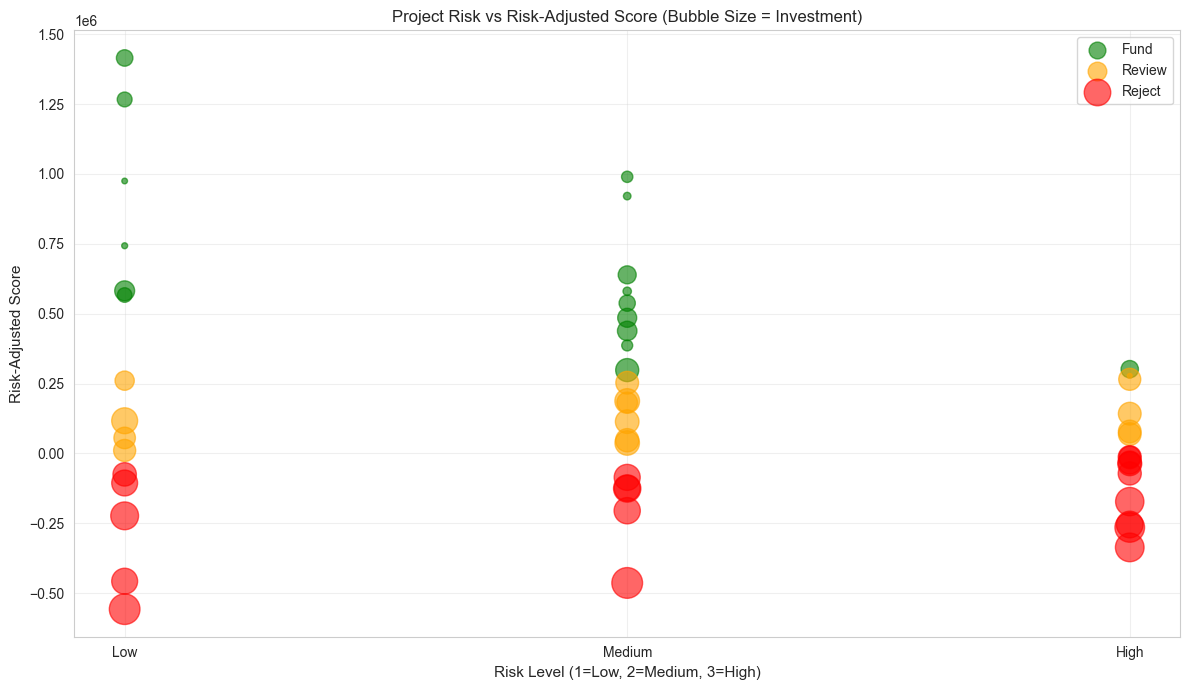

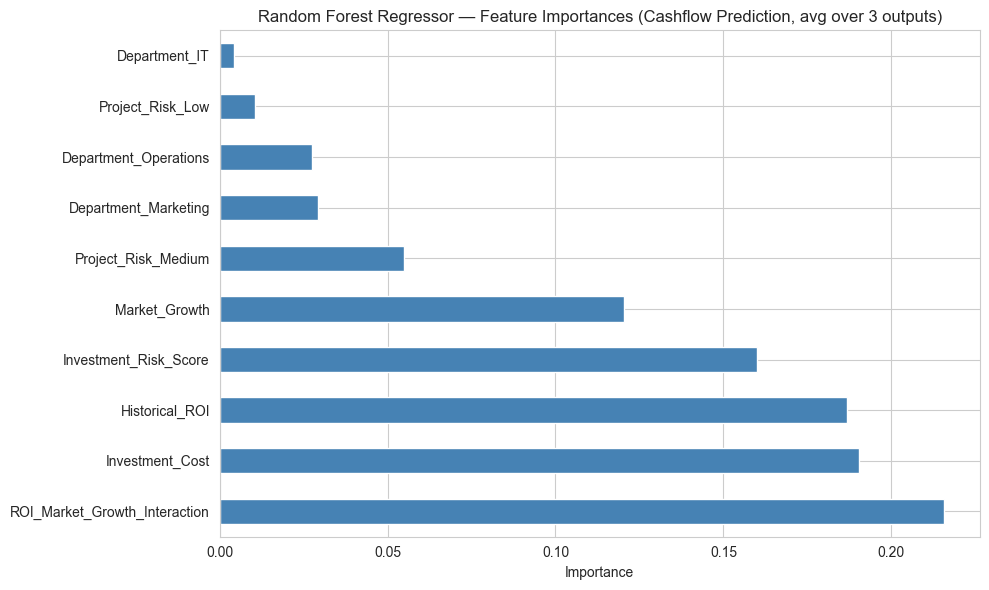


Top 10 Features for Cashflow Prediction:
ROI_Market_Growth_Interaction    0.215611
Investment_Cost                  0.190275
Historical_ROI                   0.186807
Investment_Risk_Score            0.160064
Market_Growth                    0.120268
Project_Risk_Medium              0.054955
Department_Marketing             0.029405
Department_Operations            0.027642
Project_Risk_Low                 0.010644
Department_IT                    0.004328
dtype: float64


In [216]:
# Feature importance: RF averages importance across all 3 cashflow outputs
reg_model = rf_reg_pipeline.named_steps['regressor']
feature_names_reg = (numeric_features +
                     list(rf_reg_pipeline.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .named_steps['onehot']
                         .get_feature_names_out(categorical_features)))

importances_reg = pd.Series(
    reg_model.feature_importances_,
    index=feature_names_reg
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances_reg.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Regressor — Feature Importances (Cashflow Prediction, avg over 3 outputs)')
plt.tight_layout()
plt.show()

print("\nTop 10 Features for Cashflow Prediction:")
print(importances_reg.head(10))

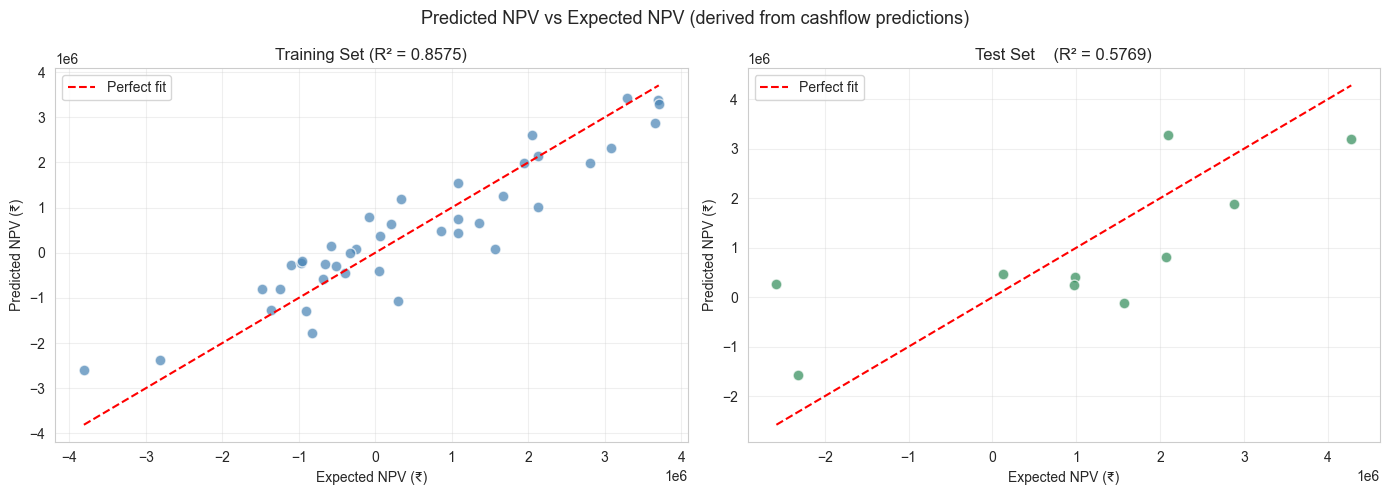

In [217]:
# ── Predicted NPV vs Expected NPV (train and test) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predicted NPV vs Expected NPV (derived from cashflow predictions)', fontsize=13)

for ax, (npv_exp, npv_pred, title, color) in zip(
    axes,
    [(npv_exp_train, npv_pred_train, f'Training Set (R² = {train_r2:.4f})', 'steelblue'),
     (npv_exp_test,  npv_pred_test,  f'Test Set    (R² = {test_r2:.4f})',  'seagreen')]
):
    ax.scatter(npv_exp, npv_pred, alpha=0.7, color=color, s=60, edgecolors='white')
    lo, hi = min(npv_exp.min(), npv_pred.min()), max(npv_exp.max(), npv_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Expected NPV (₹)')
    ax.set_ylabel('Predicted NPV (₹)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Predicted IRR (from Predicted Cashflows)

IRR is computed from the cashflows the regression model predicted.  
Projects with **Predicted IRR < 10%** (below the discount rate / hurdle rate) cannot recover their cost of capital and will be automatically rejected in the ranking step.

In [218]:
import numpy_financial as npf

def safe_irr(cashflows):
    try:
        val = npf.irr(cashflows)
        return val if np.isfinite(val) else np.nan
    except Exception:
        return np.nan

# IRR from PREDICTED cashflows
df_processed['Predicted_IRR'] = df_processed.apply(
    lambda row: safe_irr([
        -row['Investment_Cost'],
        row['Predicted_CF_Year1'],
        row['Predicted_CF_Year2'],
        row['Predicted_CF_Year3']
    ]),
    axis=1
)

# Fill NaN IRR with 0 (treat as below hurdle)
df_processed['Predicted_IRR'] = df_processed['Predicted_IRR'].fillna(0)

below_hurdle = (df_processed['Predicted_IRR'] < DISCOUNT_RATE).sum()

print("=== Predicted IRR Summary ===")
print(df_processed['Predicted_IRR'].describe().round(4))
print(f"\nProjects with Predicted IRR < {DISCOUNT_RATE:.0%} (hurdle rate): {below_hurdle}")

=== Predicted IRR Summary ===
count    50.0000
mean      0.7673
std       1.6926
min      -0.2489
25%       0.0467
50%       0.1689
75%       0.5054
max       8.1180
Name: Predicted_IRR, dtype: float64

Projects with Predicted IRR < 10% (hurdle rate): 19


## PHASE 5: Classification Module - Success Probability Prediction

In [219]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# ── Extended feature set for classification ───────────────────────
# Adds Predicted_NPV and Predicted_IRR on top of the regression features
numeric_features_clf = numeric_features + ['Predicted_NPV', 'Predicted_IRR']
categorical_features_clf = categorical_features

preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), numeric_features_clf),
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(drop='first', sparse_output=False))]),
         categorical_features_clf)
    ])

X_clf = df_processed[numeric_features_clf + categorical_features_clf].copy()
y_clf = df_processed['Success'].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Training set size: {X_train_clf.shape[0]}")
print(f"Test set size    : {X_test_clf.shape[0]}")
print(f"\nClassifier features:")
for f in numeric_features_clf + categorical_features_clf:
    tag = " ← NEW" if f in ('Predicted_NPV', 'Predicted_IRR') else ""
    print(f"  - {f}{tag}")
print(f"\nTraining success rate: {y_train_clf.mean()*100:.1f}%")
print(f"Test success rate    : {y_test_clf.mean()*100:.1f}%")

Training set size: 40
Test set size    : 10

Classifier features:
  - Investment_Cost
  - Historical_ROI
  - Market_Growth
  - Investment_Risk_Score
  - ROI_Market_Growth_Interaction
  - Predicted_NPV ← NEW
  - Predicted_IRR ← NEW
  - Department
  - Project_Risk

Training success rate: 52.5%
Test success rate    : 50.0%


In [220]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_clf),   # uses extended feature set
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

print("Training Random Forest Classifier (with Predicted NPV + IRR features)...")
rf_clf_pipeline.fit(X_train_clf, y_train_clf)

y_pred_clf_train = rf_clf_pipeline.predict(X_train_clf)
y_pred_clf_test  = rf_clf_pipeline.predict(X_test_clf)
y_prob_clf_train = rf_clf_pipeline.predict_proba(X_train_clf)[:, 1]
y_prob_clf_test  = rf_clf_pipeline.predict_proba(X_test_clf)[:, 1]

print("\n" + "="*50)
print("CLASSIFICATION MODEL PERFORMANCE (TEST SET)")
print("="*50)
print(f"\nAccuracy  : {accuracy_score(y_test_clf,  y_pred_clf_test):.4f}")
print(f"Precision : {precision_score(y_test_clf, y_pred_clf_test):.4f}")
print(f"Recall    : {recall_score(y_test_clf,    y_pred_clf_test):.4f}")
print(f"F1-Score  : {f1_score(y_test_clf,        y_pred_clf_test):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_clf,   y_prob_clf_test):.4f}")
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test_clf, y_pred_clf_test, target_names=['Failed', 'Success']))

Training Random Forest Classifier (with Predicted NPV + IRR features)...

CLASSIFICATION MODEL PERFORMANCE (TEST SET)

Accuracy  : 0.5000
Precision : 0.5000
Recall    : 0.6000
F1-Score  : 0.5455
ROC-AUC   : 0.5200

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Failed       0.50      0.40      0.44         5
     Success       0.50      0.60      0.55         5

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.50      0.50      0.49        10



In [221]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf_test)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Failed', 'Success'], yticklabels=['Failed', 'Success'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Success Prediction (Test Set)')
plt.tight_layout()

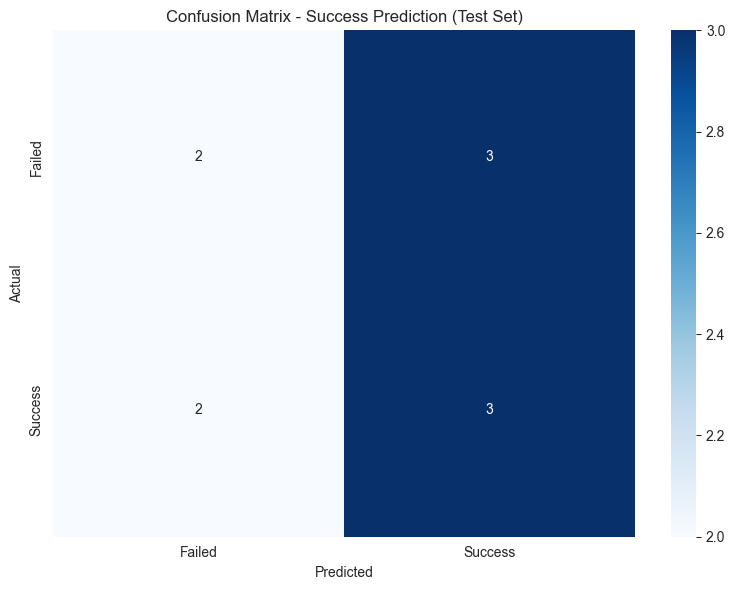

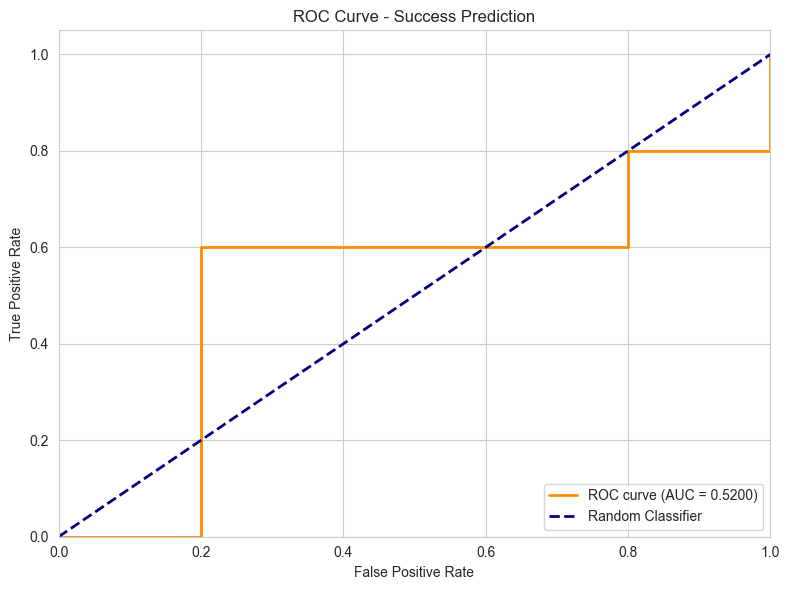

In [222]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_clf_test)
roc_auc = roc_auc_score(y_test_clf, y_prob_clf_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Success Prediction')
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

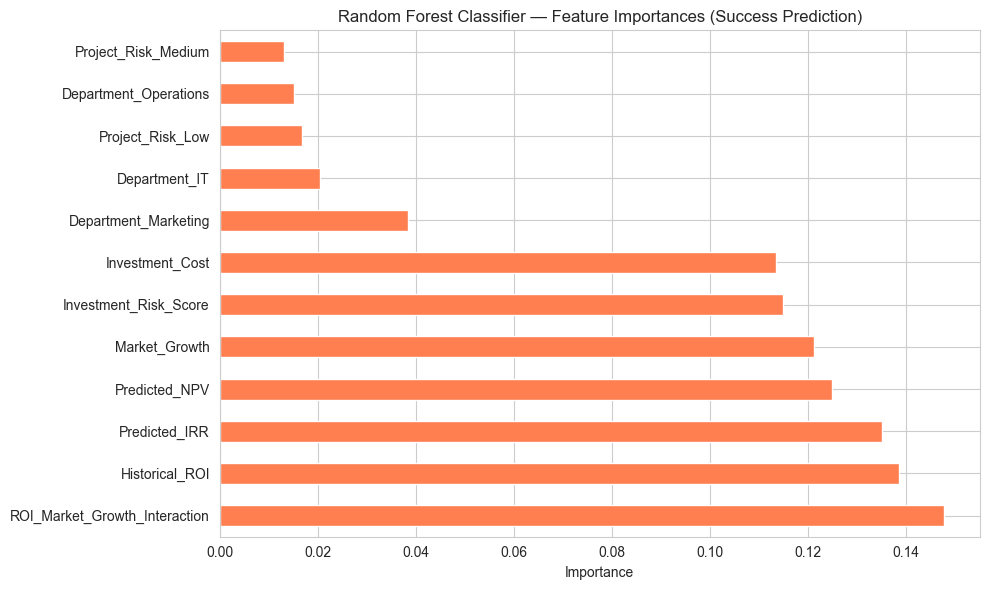


Top 10 Features for Success Prediction:
ROI_Market_Growth_Interaction    0.147714
Historical_ROI                   0.138484
Predicted_IRR                    0.135010
Predicted_NPV                    0.125013
Market_Growth                    0.121207
Investment_Risk_Score            0.114911
Investment_Cost                  0.113567
Department_Marketing             0.038502
Department_IT                    0.020459
Project_Risk_Low                 0.016875
dtype: float64


In [223]:
clf_model = rf_clf_pipeline.named_steps['classifier']

feature_names_clf = (numeric_features_clf +
                     list(rf_clf_pipeline.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .named_steps['onehot']
                         .get_feature_names_out(categorical_features_clf)))

importances_clf = pd.Series(
    clf_model.feature_importances_,
    index=feature_names_clf
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances_clf.head(15).plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Classifier — Feature Importances (Success Prediction)')
plt.tight_layout()
plt.show()

print("\nTop 10 Features for Success Prediction:")
print(importances_clf.head(10))

## PHASE 6: Generate Predictions for All Projects

In [224]:
# Predicted cashflows and NPV are already stored in df_processed from Phase 4.
# Here we generate success probabilities for all 50 projects.
X_clf_all = df_processed[numeric_features_clf + categorical_features_clf].copy()
df_processed['Predicted_Success_Probability'] = rf_clf_pipeline.predict_proba(X_clf_all)[:, 1]

print("✓ Success probabilities generated for all projects")
print(f"\nPredicted Success Probability Statistics:")
print(df_processed['Predicted_Success_Probability'].describe().round(4))

✓ Success probabilities generated for all projects

Predicted Success Probability Statistics:
count    50.0000
mean      0.5117
std       0.1949
min       0.1996
25%       0.3389
50%       0.5245
75%       0.6917
max       0.8614
Name: Predicted_Success_Probability, dtype: float64


## Business Decision Logic

The regression model predicts project NPV, while the classification model estimates the probability of project success. These two outputs are combined into Expected Value:

Expected Value = Predicted NPV × Predicted Success Probability

Projects are ranked using a Priority Score that combines expected value, risk-adjusted return, success probability, historical ROI, and risk-adjusted expected value.

## PHASE 7: Risk-Adjusted Ranking & Economic Value Calculation

In [225]:
!pip install numpy_financial -q
import numpy_financial as npf

# Expected IRR (from actual cashflows — for reference / comparison)
df_processed['Expected_IRR'] = df_processed.apply(
    lambda row: safe_irr([
        -row['Investment_Cost'],
        row['Expected_Cashflow_Year1'],
        row['Expected_Cashflow_Year2'],
        row['Expected_Cashflow_Year3']
    ]),
    axis=1
).fillna(0)

# Keep backward-compat alias used in display
df_processed['IRR'] = df_processed['Expected_IRR']

# Payback period (from expected cashflows, for display)
def calculate_payback_period(investment, cashflows):
    remaining = investment
    for i, cf in enumerate(cashflows):
        if remaining <= 0:
            break
        if cf <= 0:
            continue
        remaining -= cf
    if remaining <= 0:
        amount_needed = investment - sum(cashflows[:i])
        frac = amount_needed / cashflows[i] if cashflows[i] > 0 else 1
        return i + frac
    return np.inf

df_processed['Simple_Payback_Period'] = df_processed.apply(
    lambda row: calculate_payback_period(
        row['Investment_Cost'],
        [row['Expected_Cashflow_Year1'],
         row['Expected_Cashflow_Year2'],
         row['Expected_Cashflow_Year3']]
    ), axis=1
)

print("=== IRR Comparison ===")
comparison = df_processed[['Project_ID', 'Expected_IRR', 'Predicted_IRR']].copy()
comparison['IRR_Diff'] = comparison['Predicted_IRR'] - comparison['Expected_IRR']
print(comparison.describe().round(4))

=== IRR Comparison ===
       Project_ID  Expected_IRR  Predicted_IRR  IRR_Diff
count     50.0000       50.0000        50.0000   50.0000
mean      25.5000        0.7700         0.7673   -0.0027
std       14.5774        1.9840         1.6926    0.6625
min        1.0000       -0.5875        -0.2489   -3.3302
25%       13.2500       -0.0239         0.0467   -0.1324
50%       25.5000        0.1861         0.1689    0.0432
75%       37.7500        0.5455         0.5054    0.1505
max       50.0000       11.4482         8.1180    1.8134



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Abcom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [226]:
df_processed["Original_Index"] = df_processed.index

# =====================================================
# STEP 1: Risk-adjusted score for ALL projects
#   Score = Predicted_NPV x Success_Probability / Risk_Encoded
#   Risk_Encoded: Low=1, Medium=2, High=3
# =====================================================
df_processed['Risk_Adjusted_Score'] = (
    (df_processed['Predicted_NPV'] * df_processed['Predicted_Success_Probability'])
    / df_processed['Risk_Encoded']
)

# =====================================================
# STEP 2: Label projects
#   Hard reject : Predicted_NPV < 0  OR  Predicted_IRR < 10%
#                 OR  Predicted_Success_Probability < 40%
#   Fund        : passes hard filters AND Success_Prob >= 55%
#   Review      : passes hard filters AND 40% <= Success_Prob < 55%
# =====================================================
FUND_PROB_THRESHOLD   = 0.55   # >= 55% success probability -> Fund
REVIEW_PROB_THRESHOLD = 0.40   # 40-55% -> Review; < 40% -> Reject

reject_mask = (
    (df_processed['Predicted_NPV'] < 0)
    | (df_processed['Predicted_IRR'] < DISCOUNT_RATE)
    | (df_processed['Predicted_Success_Probability'] < REVIEW_PROB_THRESHOLD)
)
passing_mask = ~reject_mask

df_processed['Recommendation'] = 'Reject'
df_processed.loc[
    passing_mask & (df_processed['Predicted_Success_Probability'] >= FUND_PROB_THRESHOLD),
    'Recommendation'
] = 'Fund'
df_processed.loc[
    passing_mask & (df_processed['Predicted_Success_Probability'] < FUND_PROB_THRESHOLD),
    'Recommendation'
] = 'Review'

# =====================================================
# STEP 3: Final ranking
#   Primary  : Fund (1) > Review (2) > Reject (3)
#   Secondary: Risk_Adjusted_Score descending within each tier
# =====================================================
df_processed['Recommendation_Score'] = df_processed['Recommendation'].map(
    {'Fund': 1, 'Review': 2, 'Reject': 3}
)

df_ranked = df_processed.sort_values(
    ['Recommendation_Score', 'Risk_Adjusted_Score'],
    ascending=[True, False]
).reset_index(drop=True)

df_ranked['Rank'] = range(1, len(df_ranked) + 1)

print(f"Hard reject  : NPV < 0  OR  IRR < {DISCOUNT_RATE:.0%}  OR  Success Prob < {REVIEW_PROB_THRESHOLD:.0%}")
print(f"Fund         : Success Probability >= {FUND_PROB_THRESHOLD:.0%}")
print(f"Review       : {REVIEW_PROB_THRESHOLD:.0%} <= Success Probability < {FUND_PROB_THRESHOLD:.0%}")
print(f"\nProjects rejected (NPV < 0)          : {(df_processed['Predicted_NPV'] < 0).sum()}")
print(f"Projects rejected (IRR < 10%)        : {(df_processed['Predicted_IRR'] < DISCOUNT_RATE).sum()}")
print(f"Projects rejected (low success prob) : {(df_processed['Predicted_Success_Probability'] < REVIEW_PROB_THRESHOLD).sum()}")
print(f"\n✓ All 50 projects ranked")
print(f"  Fund   : {(df_ranked['Recommendation'] == 'Fund').sum()}")
print(f"  Review : {(df_ranked['Recommendation'] == 'Review').sum()}")
print(f"  Reject : {(df_ranked['Recommendation'] == 'Reject').sum()}")


Hard reject  : NPV < 0  OR  IRR < 10%  OR  Success Prob < 40%
Fund         : Success Probability >= 55%
Review       : 40% <= Success Probability < 55%

Projects rejected (NPV < 0)          : 19
Projects rejected (IRR < 10%)        : 19
Projects rejected (low success prob) : 16

✓ All 50 projects ranked
  Fund   : 16
  Review : 6
  Reject : 28


In [227]:
# # Calculate risk-adjusted metrics

# # 1. Expected Value = NPV × Success_Probability
# df_processed['Expected_Value'] = df_processed['Predicted_NPV'] * df_processed['Predicted_Success_Probability']

# # 3. Return on Investment Index = Predicted_NPV / Investment_Cost
# df_processed['ROI_Index'] = df_processed['Predicted_NPV'] / df_processed['Investment_Cost']

# # 4. Risk Score (inverse of success probability × risk level)
# df_processed['Risk_Score'] = (1 - df_processed['Predicted_Success_Probability']) * df_processed['Risk_Encoded']
# #  ==========================================
# # STEP 1: Create Capital Efficiency Metric
# # ==========================================
# # 2. Risk-Adjusted Return = Expected_Value / Investment_Cost # redundant and should not be used for ranking

# df_processed['Risk_Adjusted_Return'] = (
#     df_processed['Expected_Value'] /
#     df_processed['Investment_Cost']
# )

# # Optional: avoid infinite values
# df_processed['Risk_Adjusted_Return'] = df_processed['Risk_Adjusted_Return'].replace([np.inf, -np.inf], 0)

# # ==========================================
# # STEP 2: Normalize Metrics (0-1 Percentiles)
# # ==========================================

# df_processed['EV_Percentile'] = df_processed['Expected_Value'].rank(pct=True)

# df_processed['Success_Percentile'] = (
#     df_processed['Predicted_Success_Probability'].rank(pct=True)
# )

# df_processed['RAR_Percentile'] = (
#     df_processed['Risk_Adjusted_Return'].rank(pct=True)
# )

# df_processed['ROI_Percentile'] = (
#     df_processed['Historical_ROI'].rank(pct=True)
# )

# # LOWER risk = BETTER
# df_processed['Risk_Percentile'] = (
#     1 - df_processed['Risk_Score'].rank(pct=True)
# )
# df_processed['Risk_Adjusted_EV'] = (
#     df_processed['Expected_Value'] /
#     df_processed['Risk_Score']
# )
# df_processed['RAEV_Percentile'] = (
#     df_processed['Risk_Adjusted_EV'].rank(pct=True)
# )
# # ==========================================
# # STEP 3: Executive Priority Score
# # ==========================================

# df_processed['Priority_Score'] = (
#     0.30 * df_processed['EV_Percentile'] +
#     0.20 * df_processed['Success_Percentile'] +
#     0.25 * df_processed['RAR_Percentile'] +
#     0.10 * df_processed['ROI_Percentile'] +
#     0.15 * df_processed['RAEV_Percentile']
# )

# # ==========================================
# # STEP 4: Executive Penalty Rules
# # ==========================================
# # High risk penalty
# df_processed.loc[
#     df_processed['Risk_Score'] > 5,
#     'Priority_Score'
# ] *= 0.85

# # Low probability penalty
# df_processed.loc[
#     df_processed['Predicted_Success_Probability'] < 0.40,
#     'Priority_Score'
# ] *= 0.90

# # Negative NPV penalty
# df_processed.loc[
#     df_processed['Predicted_NPV'] < 0,
#     'Priority_Score'
# ] *= 0.50

# # Negative EV penalty
# df_processed.loc[
#     df_processed['Expected_Value'] < 0,
#     'Priority_Score'
# ] *= 0.50

# # ================================
# # STEP 5: Rank Projects by Priority Score
# # ================================


# def generate_recommendation(row):

#     if (
#         row['Expected_Value'] > 0 and
#         row['NPV'] > 0 and
#         row['Risk_Score'] <= 4 and
#         row['Predicted_Success_Probability'] >= 0.60
#     ):
#         return 'Fund'

#     elif (
#         row['Expected_Value'] < 0 or
#         row['Predicted_NPV'] < 0
#     ):
#         return 'Reject'

#     else:
#         return 'Review'


# df_processed['Recommendation'] = (
#     df_processed.apply(generate_recommendation, axis=1)
# )

# recommendation_map = {
#     'Fund': 1,
#     'Review': 2,
#     'Reject': 3
# }

# df_processed['Recommendation_Score'] = df_processed['Recommendation'].map(recommendation_map)

# # Rank all projects by Recommendation_Score (ascending: 1=Fund, 2=Review, 3=Reject), then Priority_Score
# df_ranked = df_processed.sort_values(
#     by=['Recommendation_Score', 'Priority_Score'],
#     ascending=[True, False]  # Fund first (1), then by Priority Score descending
# ).reset_index(drop=True)

# # Add Rank column - each project gets a unique sequential rank
# df_ranked['Rank'] = range(1, len(df_ranked) + 1)

# # Verify unique ranks
# print("\n✓ Projects Ranked with Unique Sequential Ranks")
# print(f"  Total Projects Ranked: {len(df_ranked)}")
# print(f"  Rank Range: {df_ranked['Rank'].min()} to {df_ranked['Rank'].max()}")
# print(f"  Unique Ranks: {df_ranked['Rank'].nunique()}")


Metric	Correlation
Market_Growth vs Predicted_NPV	-0.180
is not ideal, but it is also not necessarily wrong.
Interpretation:
-0.18 = weak negative relationship
practically close to zero
your model is saying:
higher market growth does NOT strongly increase NPV

In [ ]:
display_cols = [
    'Project_ID',
    'Department',
    'Investment_Cost',
    'NPV',                           # Expected NPV (from actual cashflows)
    'Predicted_NPV',                 # Derived from ML-predicted cashflows
    'Expected_IRR',                  # IRR from actual cashflows (reference)
    'Predicted_IRR',                 # IRR from predicted cashflows (decision driver)
    'Predicted_Success_Probability',
    'Risk_Encoded',
    'Risk_Adjusted_Score',           # Predicted_NPV × Success_Prob / Risk_Encoded
    'Recommendation',
    'Rank'
]

df_display = df_ranked[display_cols].copy()

for col in ['NPV', 'Predicted_NPV', 'Investment_Cost']:
    df_display[col] = df_display[col].apply(lambda x: f'${x:,.0f}')

df_display['Expected_IRR']  = df_display['Expected_IRR'].apply(lambda x: f'{x:.2%}')
df_display['Predicted_IRR'] = df_display['Predicted_IRR'].apply(lambda x: f'{x:.2%}')
df_display['Predicted_Success_Probability'] = df_display['Predicted_Success_Probability'].apply(
    lambda x: f'{x:.1%}')
df_display['Risk_Adjusted_Score'] = df_display['Risk_Adjusted_Score'].apply(
    lambda x: f'{x:,.0f}')

print(df_display.to_string(index=False))

df_display.to_csv('module1_ranked_projects.csv', index=False)
print("\n✓ Saved: module1_ranked_projects.csv")

 Project_ID Department Investment_Cost         NPV Predicted_NPV Expected_IRR Predicted_IRR Predicted_Success_Probability  Risk_Encoded Risk_Adjusted_Score Recommendation  Rank
         45  Marketing      $1,411,736  $2,806,794    $1,985,301      106.45%        79.85%                         71.6%             1           1,421,133           Fund     1
         39    Finance      $1,146,797  $2,131,233    $2,132,914       78.42%        83.61%                         58.5%             1           1,247,542           Fund     2
         43         IT        $664,685  $3,653,868    $2,879,294      196.41%       169.45%                         67.2%             2             967,734           Fund     3
         35         IT        $296,769  $3,690,876    $3,389,576      615.74%       477.80%                         55.1%             2             933,678           Fund     4
         41 Operations      $1,684,398  $1,937,934    $1,988,535       55.88%        61.98%                        

## PHASE 9: Export Results

## PHASE 10: SHAP Analysis for Explainability

In [229]:
# Install SHAP if not already installed
import subprocess
import sys

try:
    import shap
    print("✓ SHAP already installed")
except ImportError:
    print("Installing SHAP...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("✓ SHAP installed")

✓ SHAP already installed


In [230]:
import shap

X_processed     = rf_reg_pipeline.named_steps['preprocessor'].transform(X)
X_processed_df  = pd.DataFrame(X_processed, columns=feature_names_reg, index=X.index)

print("Creating SHAP explainer for Regression model (multi-output)...")
reg_model_final = rf_reg_pipeline.named_steps['regressor']
explainer_reg   = shap.TreeExplainer(reg_model_final)
shap_values_all = explainer_reg.shap_values(X_processed_df)

# ── Normalise to list of per-output arrays (handles both SHAP versions) ──
# Older SHAP: list of (n_samples, n_features) arrays
# Newer SHAP: single 3D array (n_samples, n_features, n_outputs)
if isinstance(shap_values_all, list):
    sv_list = shap_values_all                              # already a list
else:
    sv_list = [shap_values_all[:, :, i]
               for i in range(shap_values_all.shape[2])]  # split on last axis

# ── Aggregate into NPV SHAP using discount factors ────────────────
discount_factors = np.array([1/(1+DISCOUNT_RATE)**1,
                              1/(1+DISCOUNT_RATE)**2,
                              1/(1+DISCOUNT_RATE)**3])

shap_values_reg = sum(sv * d for sv, d in zip(sv_list, discount_factors))

# ── Aggregate expected_value the same way ────────────────────────
ev_raw = explainer_reg.expected_value
if hasattr(ev_raw, '__len__'):
    expected_val_reg = sum(float(ev_raw[i]) * discount_factors[i] for i in range(3))
else:
    expected_val_reg = float(ev_raw)

print(f"✓ SHAP values aggregated into NPV units (₹)")
print(f"  SHAP array shape : {shap_values_reg.shape}")
print(f"  Expected value   : ₹{expected_val_reg:,.0f}")

Creating SHAP explainer for Regression model (multi-output)...
✓ SHAP values aggregated into NPV units (₹)
  SHAP array shape : (50, 10)
  Expected value   : ₹3,042,574


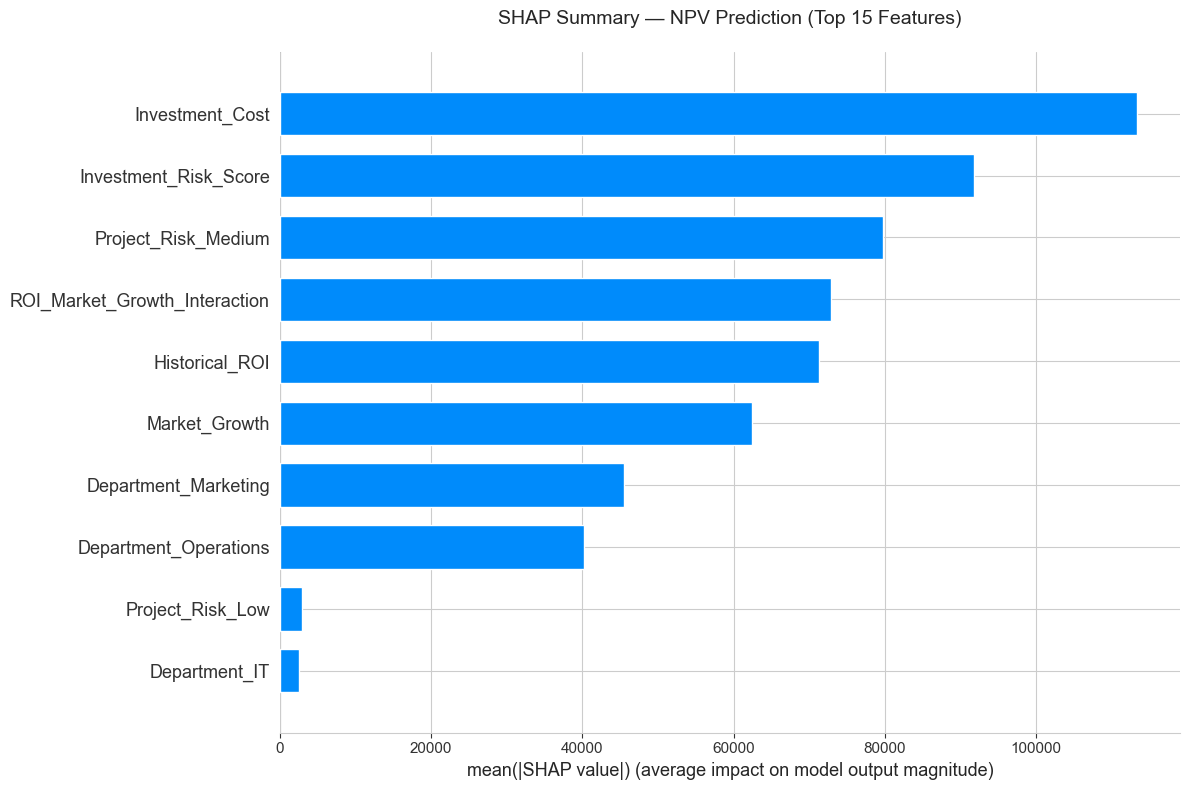

✓ Saved: 01_shap_summary_regression.png


In [231]:
# shap creates its own figure — resize/title it after the call
shap.summary_plot(
    shap_values_reg,
    X_processed_df,       # DataFrame: column names are picked up automatically
    plot_type='bar',
    max_display=15,
    show=False
)
plt.gcf().set_size_inches(12, 8)
plt.title('SHAP Summary — NPV Prediction (Top 15 Features)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('01_shap_summary_regression.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 01_shap_summary_regression.png")

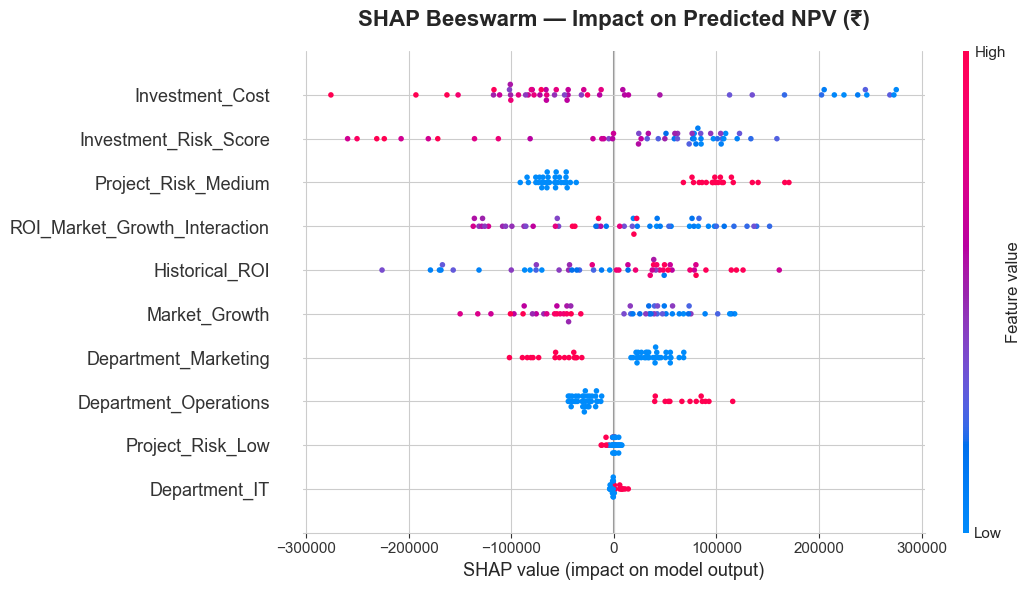

✓ Saved: 02_shap_beeswarm_regression.png


In [232]:
shap.summary_plot(
    shap_values_reg,
    X_processed_df,
    max_display=10,
    show=False
)
plt.gcf().set_size_inches(11, 6)
plt.title("SHAP Beeswarm — Impact on Predicted NPV (₹)",
          fontsize=16, fontweight="bold", pad=18)
plt.tight_layout()
plt.savefig("02_shap_beeswarm_regression.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: 02_shap_beeswarm_regression.png")

✓ Saved: 03_shap_waterfall_regression_project_45.png


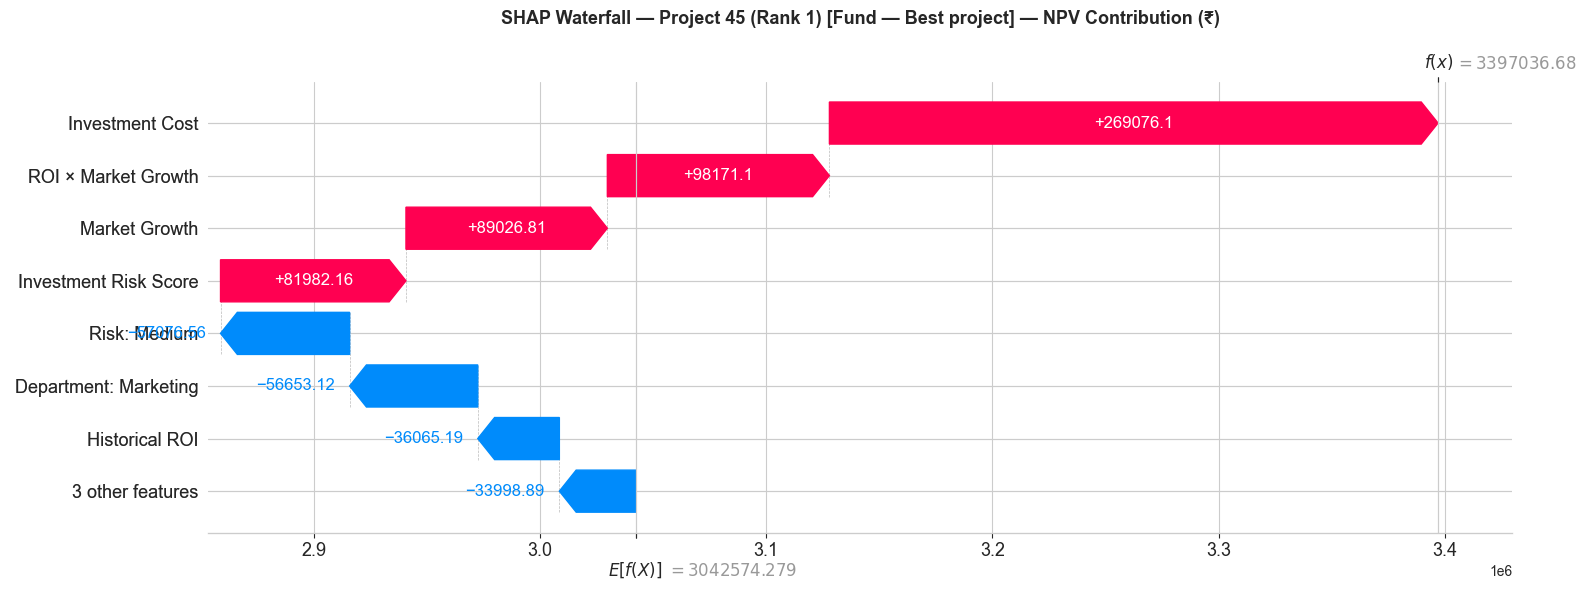

✓ Saved: 04_shap_waterfall_regression_project_37.png


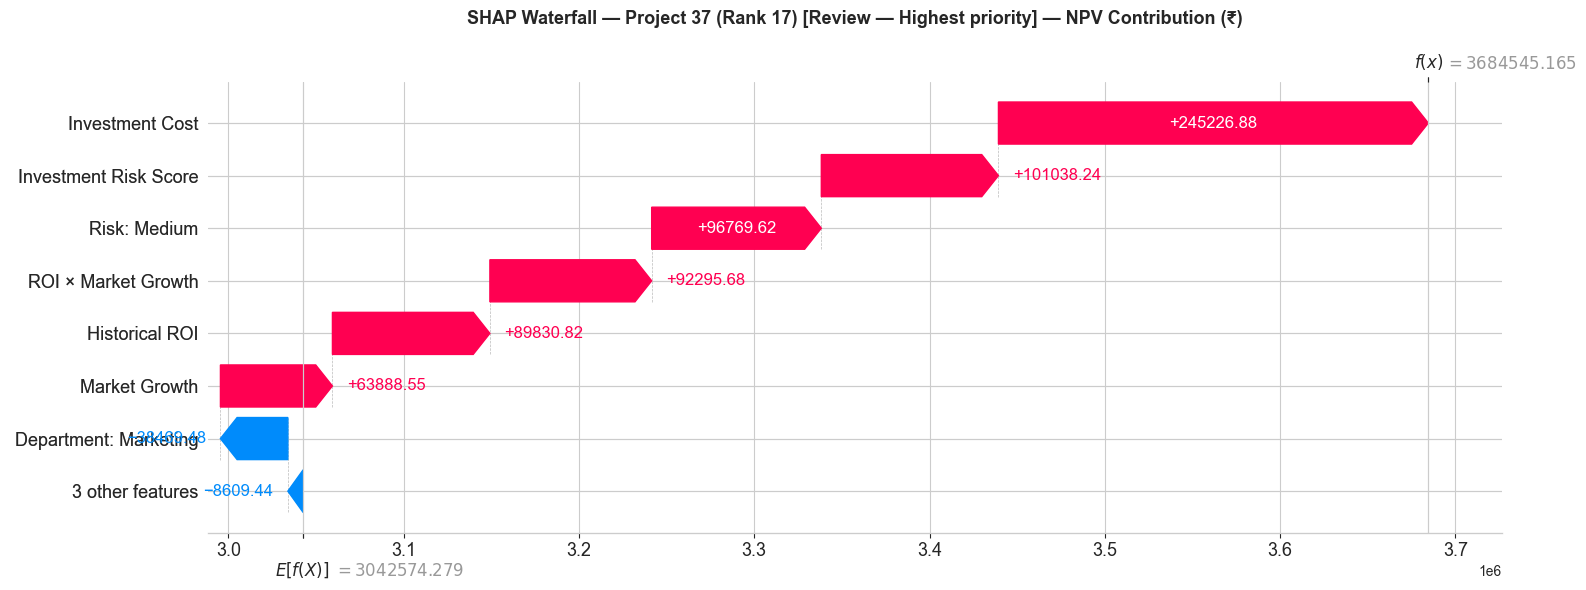

✓ Saved: 05_shap_waterfall_regression_project_47.png


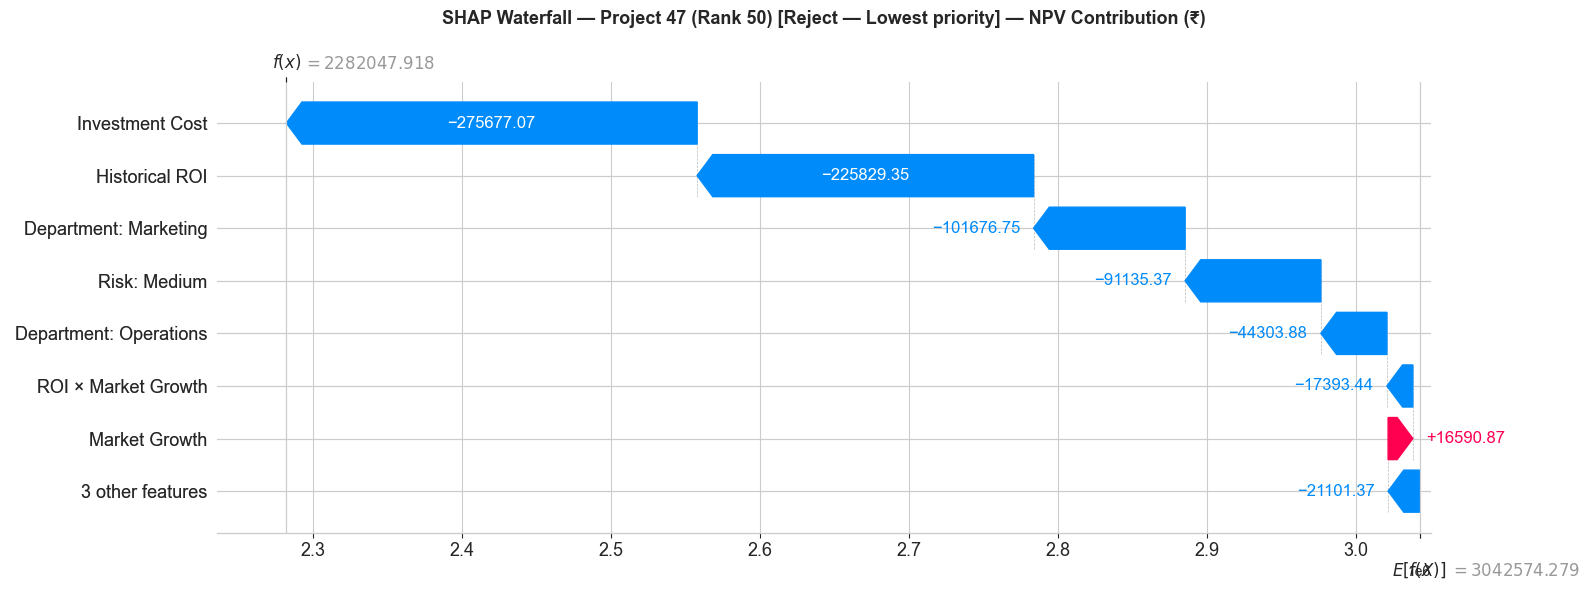

In [233]:
plt.close("all")

clean_feature_names = [
    name.replace("Investment_Cost",           "Investment Cost")
        .replace("Investment_Risk_Score",     "Investment Risk Score")
        .replace("Historical_ROI",            "Historical ROI")
        .replace("ROI_Market_Growth_Interaction", "ROI × Market Growth")
        .replace("Market_Growth",             "Market Growth")
        .replace("Department_",               "Department: ")
        .replace("Project_Risk_",             "Risk: ")
    for name in feature_names_reg
]

fund_projects   = df_ranked[df_ranked["Recommendation"] == "Fund"]
review_projects = df_ranked[df_ranked["Recommendation"] == "Review"]
reject_projects = df_ranked[df_ranked["Recommendation"] == "Reject"]

selected_projects = []
if not fund_projects.empty:
    selected_projects.append(("Fund — Best project",       fund_projects.iloc[0]))
if not review_projects.empty:
    selected_projects.append(("Review — Highest priority", review_projects.iloc[0]))
if not reject_projects.empty:
    selected_projects.append(("Reject — Lowest priority",  reject_projects.iloc[-1]))

# sv_list is already the per-output list; shap_values_reg is the NPV-aggregated 2D array
file_counter = 3
for label, project_row in selected_projects:
    project_id   = int(project_row["Project_ID"])
    # locate the row in X_processed_df (same index as df_processed)
    original_idx = df_processed.index[df_processed["Project_ID"] == project_id][0]
    row_pos      = X_processed_df.index.get_loc(original_idx)

    plt.close("all")
    shap.plots._waterfall.waterfall_legacy(
        expected_val_reg,
        shap_values_reg[row_pos],
        X_processed_df.iloc[row_pos].values,
        feature_names=clean_feature_names,
        max_display=8,
        show=False
    )
    plt.gcf().set_size_inches(16, 6)
    plt.title(
        f"SHAP Waterfall — Project {project_id} "
        f"(Rank {int(project_row['Rank'])}) [{label}] — NPV Contribution (₹)",
        fontsize=13, fontweight="bold", pad=20
    )
    plt.tight_layout()

    fname = f"{file_counter:02d}_shap_waterfall_regression_project_{project_id}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    print(f"✓ Saved: {fname}")
    plt.show()
    plt.close("all")
    file_counter += 1

In [234]:
print("Creating SHAP explainer for Classification model...")
clf_model_final = rf_clf_pipeline.named_steps['classifier']
X_processed_clf = rf_clf_pipeline.named_steps['preprocessor'].transform(X_clf_all)
X_clf_df        = pd.DataFrame(X_processed_clf, columns=feature_names_clf, index=X_clf_all.index)

explainer_clf   = shap.TreeExplainer(clf_model_final)
shap_values_clf = explainer_clf.shap_values(X_clf_df)

# ── Normalise to list of per-class arrays ────────────────────────
if isinstance(shap_values_clf, list):
    sv_clf_list = shap_values_clf
else:
    sv_clf_list = [shap_values_clf[:, :, i]
                   for i in range(shap_values_clf.shape[2])]

print(f"✓ SHAP explainer created")
print(f"  Class 0 (Fail)    shape : {sv_clf_list[0].shape}")
print(f"  Class 1 (Success) shape : {sv_clf_list[1].shape}")

Creating SHAP explainer for Classification model...
✓ SHAP explainer created
  Class 0 (Fail)    shape : (50, 12)
  Class 1 (Success) shape : (50, 12)


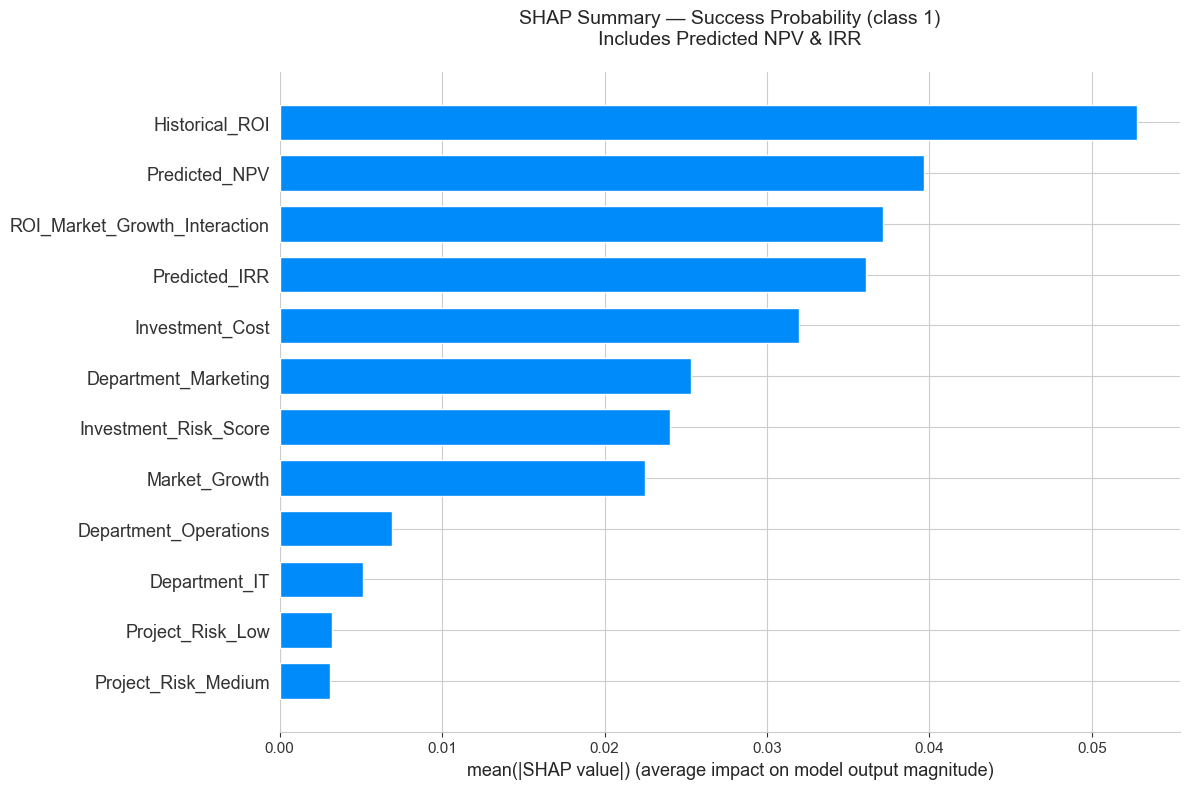

✓ Saved: 06_shap_summary_classification.png


In [235]:
import os
os.makedirs('../outputs', exist_ok=True)

shap.summary_plot(
    sv_clf_list[1],
    X_clf_df,             # DataFrame: column names picked up automatically
    plot_type='bar',
    max_display=15,
    show=False
)
plt.gcf().set_size_inches(12, 8)
plt.title('SHAP Summary — Success Probability (class 1)\nIncludes Predicted NPV & IRR',
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../outputs/06_shap_summary_classification.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 06_shap_summary_classification.png")

## PHASE 11: Executive Summary & Key Insights

In [236]:
# Create visualization: Risk vs Return Scatter
fig, ax = plt.subplots(figsize=(12, 7))

colors = {'Fund': 'green', 'Review': 'orange', 'Reject': 'red'}
for rec, color in colors.items():
    subset = df_ranked[df_ranked["Recommendation"] == rec]
    if subset.empty:
        continue
    ax.scatter(subset["Risk_Encoded"], subset["Risk_Adjusted_Score"],
               s=subset["Investment_Cost"] / 10000, alpha=0.6, label=rec, color=color)

ax.set_xlabel("Risk Level (1=Low, 2=Medium, 3=High)", fontsize=11)
ax.set_ylabel("Risk-Adjusted Score", fontsize=11)
ax.set_title("Project Risk vs Risk-Adjusted Score (Bubble Size = Investment)", fontsize=12)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Low", "Medium", "High"])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 📊 Finance Executive Review - Essential Columns for Validation

**These columns allow a finance executive to independently verify that each project's FUND/REVIEW/REJECT classification is correct.**

## PHASE 12: Spot checks

In [237]:
def validate_project_recommendation(project_id):
    """Validate a project's Fund/Review/Reject classification against the two-step logic."""
    proj = df_processed[df_processed['Project_ID'] == project_id]
    if proj.empty:
        print(f"Project {project_id} not found"); return
    proj = proj.iloc[0]
    rank = int(df_ranked[df_ranked['Project_ID'] == project_id]['Rank'].values[0])

    print("\n" + "="*80)
    print(f"  PROJECT {int(proj['Project_ID'])}  |  {proj['Department']}  "
          f"|  Risk: {proj['Project_Risk']}  |  Rank: {rank}")
    print("="*80)

    npv_ok  = proj['Predicted_NPV'] > 0
    irr_ok  = proj['Predicted_IRR'] >= DISCOUNT_RATE
    prob_ok = proj['Predicted_Success_Probability'] >= REVIEW_PROB_THRESHOLD
    passes  = npv_ok and irr_ok and prob_ok

    print(f"\n  HARD REJECT CRITERIA (any one triggers Reject):")
    print(f"    Predicted NPV > 0              : ${proj['Predicted_NPV']:>14,.0f}   {'✓ PASS' if npv_ok  else '✗ FAIL -> REJECT'}")
    print(f"    Predicted IRR >= {DISCOUNT_RATE:.0%}            : {proj['Predicted_IRR']:>14.2%}   {'✓ PASS' if irr_ok  else '✗ FAIL -> REJECT'}")
    print(f"    Success Prob >= {REVIEW_PROB_THRESHOLD:.0%}            : {proj['Predicted_Success_Probability']:>14.1%}   {'✓ PASS' if prob_ok else '✗ FAIL -> REJECT'}")
    print(f"    (Expected IRR for reference    : {proj['Expected_IRR']:.2%})")
    print(f"\n  Eligible for Fund/Review : {'YES' if passes else 'NO — labelled REJECT'}")

    if passes:
        prob  = proj['Predicted_Success_Probability']
        score = proj['Risk_Adjusted_Score']
        label = 'FUND' if prob >= FUND_PROB_THRESHOLD else 'REVIEW'

        print(f"\n  FUND / REVIEW SPLIT (Success Probability thresholds):")
        print(f"    Success Probability : {prob:.1%}")
        print(f"    >= {FUND_PROB_THRESHOLD:.0%} -> FUND  |  {REVIEW_PROB_THRESHOLD:.0%} to {FUND_PROB_THRESHOLD:.0%} -> REVIEW")
        print(f"    -> {label}")
        print(f"\n  SCORE = Predicted_NPV x Success_Prob / Risk_Encoded")
        print(f"    = ${proj['Predicted_NPV']:,.0f} x {prob:.1%} / {proj['Risk_Encoded']:.0f}")
        print(f"    = {score:,.0f}")

    print("\n" + "="*80)
    print(f"  FINAL: Project {int(proj['Project_ID'])} -> {proj['Recommendation']}")
    print("="*80)

validate_project_recommendation(3)



  PROJECT 3  |  Finance  |  Risk: High  |  Rank: 12

  HARD REJECT CRITERIA (any one triggers Reject):
    Predicted NPV > 0              : $     1,007,723   ✓ PASS
    Predicted IRR >= 10%            :         29.53%   ✓ PASS
    Success Prob >= 40%            :          72.4%   ✓ PASS
    (Expected IRR for reference    : 49.14%)

  Eligible for Fund/Review : YES

  FUND / REVIEW SPLIT (Success Probability thresholds):
    Success Probability : 72.4%
    >= 55% -> FUND  |  40% to 55% -> REVIEW
    -> FUND

  SCORE = Predicted_NPV x Success_Prob / Risk_Encoded
    = $1,007,723 x 72.4% / 3
    = 243,109

  FINAL: Project 3 -> Fund
